# Universidad Mayor
# Machine Learning - Trabajo Sumativo Unidad 1

### Predicción de PM2.5 usando variables meteorológicas y contaminantes atmosféricos

#### Integrantes

- Camilo Cáceres

- Nicolás Cruz

- Bruno Yañez

#### Asignatura: Machine Learning

###· Fecha: 24.08.2026

# Introducción

La contaminación atmosférica constituye uno de los principales problemas ambientales a nivel mundial. En este trabajo se utiliza un conjunto de datos de calidad del aire que contiene concentraciones de contaminantes atmosféricos (SO2, NO2 y O3), variables meteorológicas y concentraciones de PM2.5.

El objetivo es desarrollar un pipeline reproducible de Machine Learning para apoyar la predicción de PM2.5, aplicando los conceptos revisados en la Unidad 1: frameworks analíticos, exploración de datos, data wrangling, tratamiento de outliers, análisis de valores faltantes, ventanas de desarrollo y reproducibilidad mediante GitHub.

# 1. Frameworks para Analítica y Machine Learning

Desde bibliografía especializada, hemos hallado 3 Frameworks típicos para esta disciplina (González-Ramírez et al., 2025):

## 1. CRISP-DM

### Descripción
Metodología clásica compuesta por:

1. Comprensión del negocio
2. Comprensión de los datos
3. Preparación de datos
4. Modelado
5. Evaluación
6. Despliegue

### Alcances
- Fácil adopción.
- Amplio uso industrial.
- Compatible con cualquier herramienta.

### Limitaciones
- No define control de versiones.
- No incorpora MLOps de forma explícita.

---

## 2. TDSP (Team Data Science Process)

### Descripción
Framework propuesto por Microsoft para proyectos colaborativos.

### Alcances
- Integra Git.
- Integra despliegue.
- Facilita trabajo en equipo.

### Limitaciones
- Más complejo para proyectos pequeños.
- Dependiente de ecosistemas empresariales.

---

## 3. KDD (Knowledge Discovery in Databases)

### Descripción
Framework orientado al descubrimiento de conocimiento.

### Alcances
- Excelente para análisis exploratorio.
- Muy útil para minería de datos.

### Limitaciones
- Menos orientado a producción.
- Menor enfoque en despliegue.

---

## Framework seleccionado

Se selecciona CRISP-DM debido a que:

- El problema es predictivo.
- El dataset es relativamente pequeño (1320 registros).
- El flujo del trabajo encaja perfectamente con las fases solicitadas en la evaluación.
- Facilita la trazabilidad entre exploración, preparación y modelado.

In [2]:
# Cargamos datos

import pandas as pd
import numpy as np

df = pd.read_csv("datos.csv")

In [3]:
print(df.shape)

(1320, 8)


In [4]:
df.head()

,SO2,NO2,O3,Temperature,Humidity,Pressure,WindSpeed,PM2_5
0,42.53,52.78,34.22,1.7,62.8,1019.3,4.60,50.5
1,34.65,2.74,2.02,18.0,34.0,1014.8,25.56,10.0
2,46.10,57.51,40.13,-8.2,37.7,1002.7,6.79,34.9
3,27.58,39.51,51.83,10.1,64.0,1013.8,1.96,43.4
4,50.75,34.28,60.04,35.1,67.5,1011.1,1.91,49.4


# EDA

# 2. Exploración de Datos

El conjunto de datos contiene:

- SO2: Dióxido de azufre
- NO2: Dióxido de nitrógeno
- O3: Ozono
- Temperature
- Humidity
- Pressure
- WindSpeed
- PM2_5 (variable objetivo)

El problema corresponde a aprendizaje supervisado de regresión, pues existe una variable objetivo continua denominada PM2_5.

In [5]:
# Obtenemos información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1320 entries, 0 to 1319
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SO2          1320 non-null   float64
 1   NO2          1320 non-null   float64
 2   O3           1320 non-null   float64
 3   Temperature  1320 non-null   float64
 4   Humidity     1320 non-null   float64
 5   Pressure     1320 non-null   float64
 6   WindSpeed    1320 non-null   float64
 7   PM2_5        1320 non-null   float64
dtypes: float64(8)
memory usage: 82.6 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SO2,1320.0,40.180917,20.594914,-17.96,26.4175,40.485,53.8625,120.33
NO2,1320.0,50.107114,24.820915,-20.79,32.9150,49.710,67.9375,134.28
O3,1320.0,45.596674,20.412886,-24.80,32.1175,46.070,59.2850,105.64
Temperature,1320.0,15.001894,11.913886,-30.20,7.1000,15.100,23.1000,49.10
Humidity,1320.0,60.103333,19.825383,0.00,46.0750,59.500,73.7250,115.00
Pressure,1320.0,1012.933561,9.818485,981.10,1006.1750,1013.100,1019.9000,1043.80
WindSpeed,1320.0,5.035242,5.157417,0.01,1.4075,3.340,6.9025,35.53
PM2_5,1320.0,46.314394,21.176212,10.00,30.9000,47.300,61.1750,114.10


In [7]:
# Cuantificamos los datos nulos
df.isnull().sum()

,0
SO2,0
NO2,0
O3,0
Temperature,0
Humidity,0
Pressure,0
WindSpeed,0
PM2_5,0


### Análisis de Missing Values

La inspección confirma que no existen valores faltantes en ninguna variable.

Por lo tanto:

- No es necesario aplicar imputación.
- No es necesario eliminar registros.
- Se documenta igualmente esta validación por buenas prácticas de Data Wrangling (Kang, 2017).

In [8]:
# Buscamos duplicados

df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

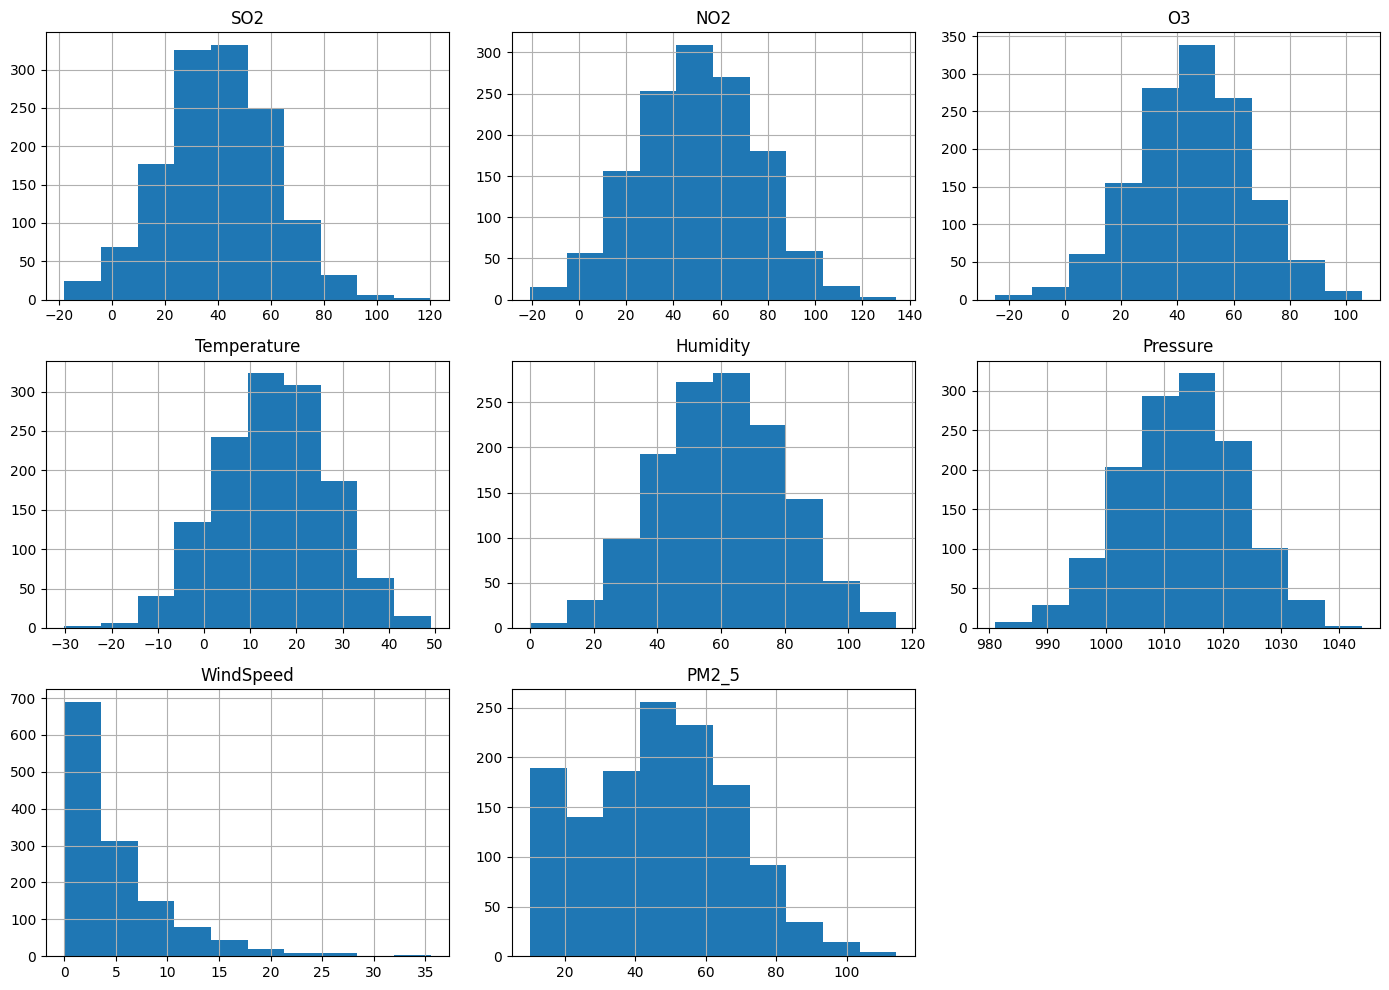

In [10]:
#histograma

import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

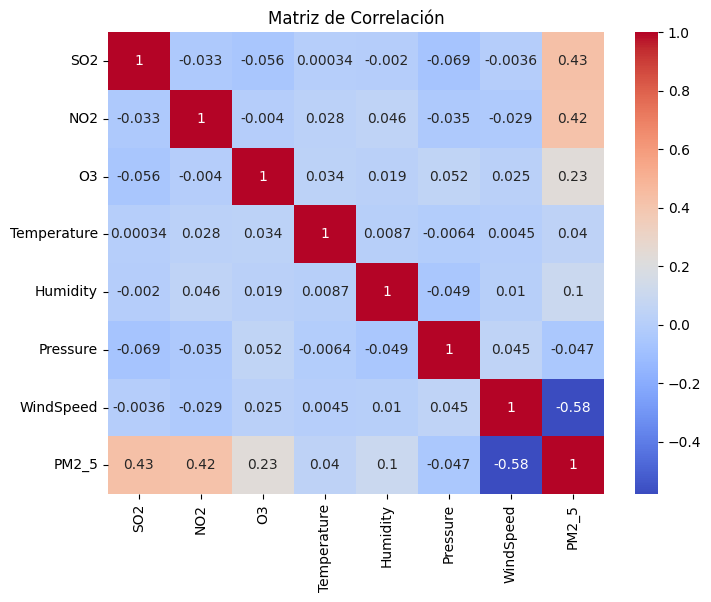

In [11]:
#Heatmap para ver correlaciones

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")
plt.show()

Las variables con mayor correlación respecto a PM2.5 serán las consideradas potencialmente importantes para el modelado posterior.

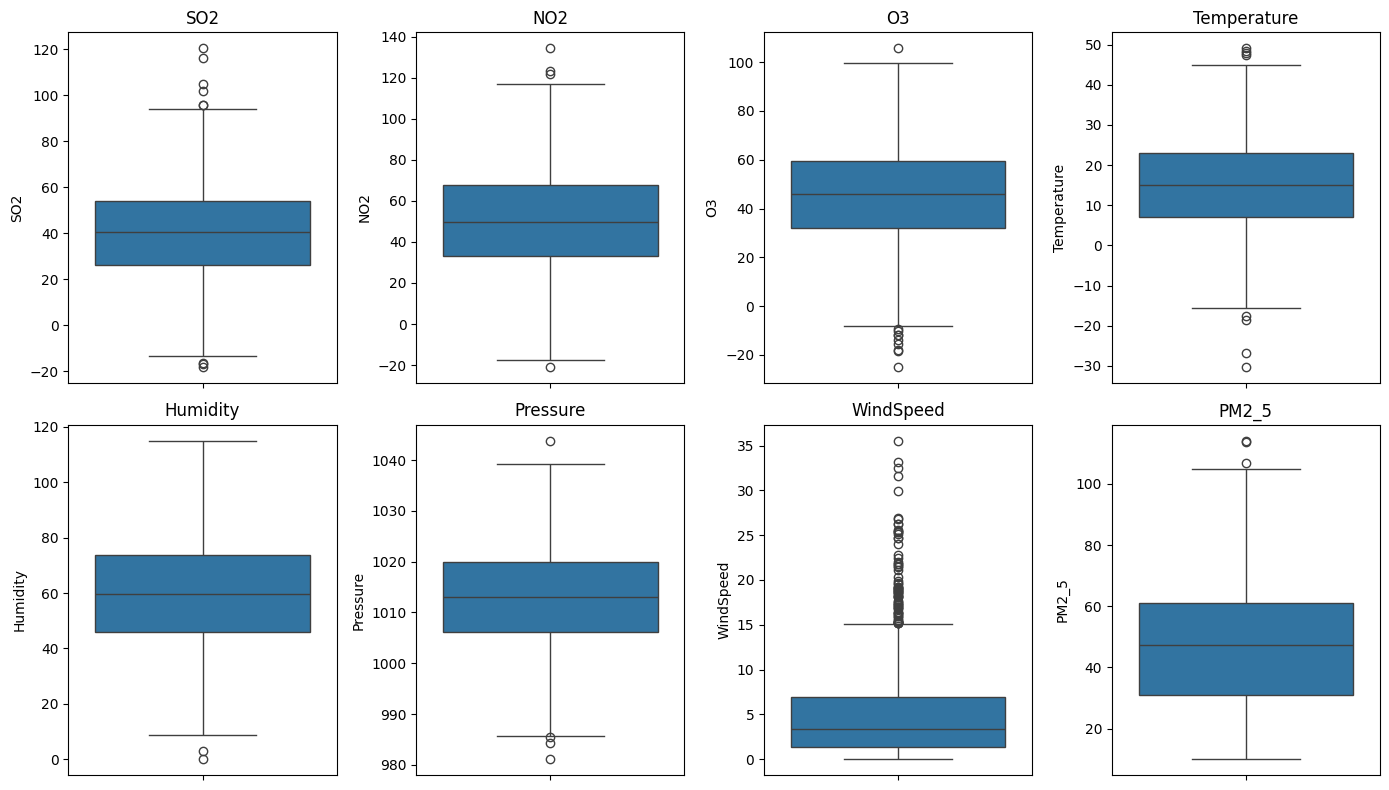

In [12]:
# Para outliers trabajaremos con boxplot (IQR)

fig, axes = plt.subplots(2,4, figsize=(14,8))

for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [13]:
def count_outliers_iqr(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    return ((series < lower) | (series > upper)).sum()

for c in df.columns:
    print(c, count_outliers_iqr(df[c]))

SO2 9
NO2 4
O3 10
Temperature 8
Humidity 2
Pressure 4
WindSpeed 71
PM2_5 3


In [14]:
# Aplicamos winsorización para no eliminar información de contaminantes

df_clean = df.copy()

for c in df_clean.columns:

    p1 = df_clean[c].quantile(0.01)
    p99 = df_clean[c].quantile(0.99)

    df_clean[c] = df_clean[c].clip(p1,p99)

Se opta por Winsorización en lugar de eliminación debido a que:

- Los extremos pueden representar instancias reales de contaminación.
- Consideramos que eliminar registros podría introducir sesgo.
- La Winsorización reduce la influencia de valores extremos sin perder observaciones.

Esta decisión se tomó basado en las recomendaciones indicadas para tratamiento de outliers discutidas en el documento de la Unidad 1.

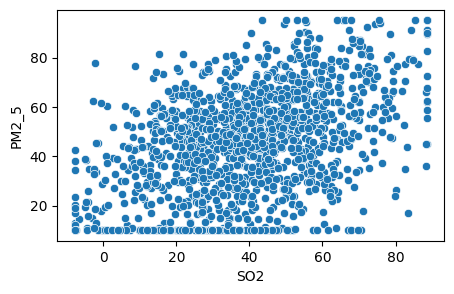

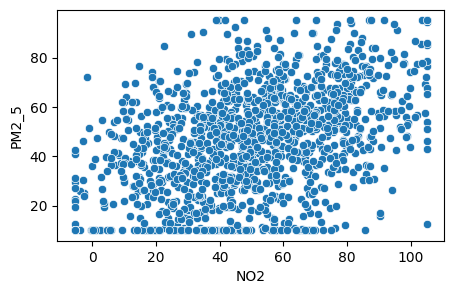

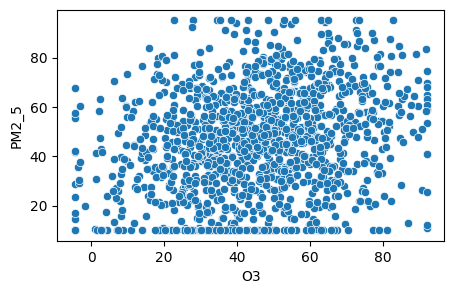

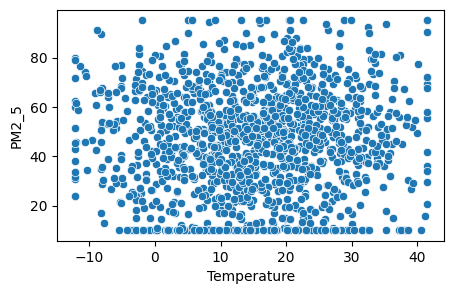

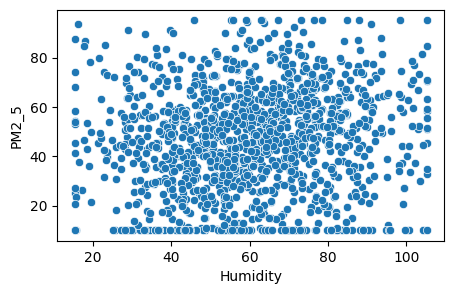

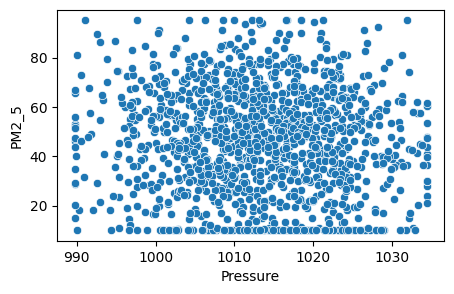

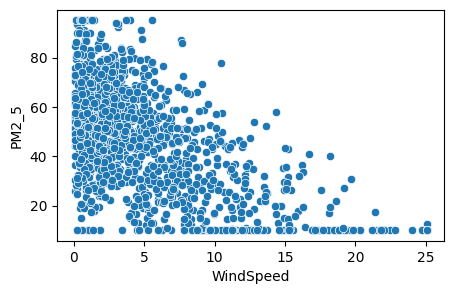

In [15]:
# Correlacionamos con PM2.5

features = df_clean.drop(columns="PM2_5")

for col in features.columns:

    plt.figure(figsize=(5,3))

    sns.scatterplot(
        data=df_clean,
        x=col,
        y="PM2_5"
    )

    plt.show()

### Hold-Out

70% entrenamiento
15% validación
15% test

Ventajas:
- Simple
- Rápido

Desventajas:
- Dependencia de una sola partición

### Train-Test Split

80% entrenamiento
20% test

Ventajas:
- Fácil implementación

Desventajas:
- Sin conjunto explícito de validación

### K-Fold Cross Validation

Ventajas:
- Mejor aprovechamiento de datos.
- Evaluación más robusta.

Desventajas:
- Mayor costo computacional.

Se selecciona Hold-Out 70/15/15.

Argumentos:

- Dataset de tamaño moderado (1320 observaciones).
- Permite disponer simultáneamente de entrenamiento, validación y test.
- Facilita futuras etapas de ajuste.

In [16]:
# Aplicamos la elección

from sklearn.model_selection import train_test_split

X = df_clean.drop(columns="PM2_5")
y = df_clean["PM2_5"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(924, 7)
(198, 7)
(198, 7)


# Conclusiones

- Se identificó que el problema corresponde a aprendizaje supervisado de regresión.
- Se compararon los frameworks CRISP-DM, TDSP y KDD, seleccionando CRISP-DM por su adaptación al problema.
- El EDA permitió comprender el comportamiento de las variables de contaminación atmosférica y meteorológicas.
- No se detectaron valores faltantes.
- Los outliers fueron tratados mediante Winsorización para preservar información relevante.
- Se evaluaron distintos métodos de partición de datos y se seleccionó Hold-Out 70/15/15.
- Se definió una estructura mediante GitHub, README.md

El trabajo cumple los principios de preparación de datos, validación y reproducibilidad revisados en la Unidad 1.

# Referencias

###### González-Ramírez, C. T., Coria-Tavira, A., Ruiz-Garduño, J. K., & Viñas-Alvarez, S. E. (2025). Data Science Methodologies: The Relevance of CRISP-DM and Its Comparison with Emerging Models. Revista de Tecnologías Computacionales, 9(22), 1-8. https://doi.org/10.35429/JOCT.2025.9.22.3.1.8.

###### Kang, H. (2017). Statistical data preparation: management of missing values and outliers. Korean Journal of Anesthesiology, 70(4), 407–411. https://doi.org/10.4097/kjae.2017.70.4.407